# Part 1 - Knowledge reasoning with SWRL

In [1]:
!pip install owlready2 rdflib pandas numpy matplotlib scikit-learn pykeen -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!java -version

java version "26" 2026-03-17
Java(TM) SE Runtime Environment (build 26+35-2893)
Java HotSpot(TM) 64-Bit Server VM (build 26+35-2893, mixed mode, sharing)


In [3]:
from owlready2 import *
import owlready2

# 1) Indiquer Java explicitement
owlready2.JAVA_EXE = r"C:\Program Files\Java\jdk-26\bin\java.exe"

# 2) Charger l'ontologie
onto = get_ontology("family.owl").load()

# 3) Vérifier les noms exacts présents dans l'ontologie
print("Classes :")
for c in onto.classes():
    print("-", c)

print("\nData properties :")
for p in onto.data_properties():
    print("-", p)

Classes :
- family.Son
- family.Child
- family.Daughter
- family.Person
- family.Uncle
- family.Parent
- family.Male
- family.Grandmother
- family.Grandparents
- family.Female
- family.Grandfather
- family.Father
- family.Mother
- family.Sibling
- family.Brother
- family.Sister

Data properties :
- family.age
- family.nationality
- family.name


In [4]:
from owlready2 import Imp, Thing

with onto:
    class oldPerson(Thing):
        pass

    rule = Imp()
    rule.set_as_rule("""
        Person(?p), age(?p, ?a), greaterThan(?a, 60) -> oldPerson(?p)
    """)

print("Règle SWRL :")
print(rule)

Règle SWRL :
Person(?p), age(?p, ?a), greaterThan(?a, 60) -> oldPerson(?p)


In [5]:
with onto:
    sync_reasoner_pellet(infer_property_values=True, infer_data_property_values=True)

print("Instances de oldPerson :")
for x in oldPerson.instances():
    print("-", x)

* Owlready2 * Running Pellet...
    C:\Program Files\Java\jdk-26\bin\java.exe -Xmx2000M -cp C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\jena-arq-fixed2.10.0.jar;C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\jena-core-fixed2.10.0.jar;C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\jena-iri-0.9.5.jar;C:\Users\Gabriel\anaconda3\Lib\site-packages\owlready2\pellet\jena-tdb-0.10.

Instances de oldPerson :
- family.Peter
- family.Marie


# Part 2 - Knowledge Graph Embedding

# 1 — Data Preparation

In [6]:
from rdflib import Graph, URIRef, Literal, BNode
import random

# =========================
# 1) LOAD KB
# =========================
g = Graph()
g.parse("expanded_kb_pruned.ttl", format="turtle")

print("Nombre de triplets bruts :", len(g))

# =========================
# 2) CLEANING
# =========================
clean_triplets = set()

for s, p, o in g:
    # garder seulement les vrais triplets entité-relation-entité
    if isinstance(s, URIRef) and isinstance(p, URIRef) and isinstance(o, URIRef):
        clean_triplets.add((str(s), str(p), str(o)))

print("Triplets après nettoyage :", len(clean_triplets))

# =========================
# 3) BUILD ENTITY / RELATION SETS
# =========================
entities = set()
relations = set()

for s, p, o in clean_triplets:
    entities.add(s)
    entities.add(o)
    relations.add(p)

print("Nombre d'entités :", len(entities))
print("Nombre de relations :", len(relations))

# =========================
# 4) UNIQUE INDEXING
# =========================
entity2id = {e: i for i, e in enumerate(sorted(entities))}
relation2id = {r: i for i, r in enumerate(sorted(relations))}

indexed_triplets = [
    (entity2id[s], relation2id[p], entity2id[o])
    for s, p, o in clean_triplets
]

print("Triplets indexés :", len(indexed_triplets))

# =========================
# 5) TRAIN / VALID / TEST SPLIT
# =========================
random.seed(42)
random.shuffle(indexed_triplets)

n = len(indexed_triplets)
train = indexed_triplets[:int(0.8 * n)]
valid = indexed_triplets[int(0.8 * n):int(0.9 * n)]
test  = indexed_triplets[int(0.9 * n):]

# =========================
# 6) ENSURE NO ENTITY ONLY IN VALID/TEST
# =========================
train_entities = set()
for h, r, t in train:
    train_entities.add(h)
    train_entities.add(t)

valid = [(h, r, t) for (h, r, t) in valid if h in train_entities and t in train_entities]
test  = [(h, r, t) for (h, r, t) in test  if h in train_entities and t in train_entities]

print("Train size :", len(train))
print("Valid size :", len(valid))
print("Test size  :", len(test))

# =========================
# 7) SAVE FILES
# =========================
def save_triplets(filename, triplets):
    with open(filename, "w", encoding="utf-8") as f:
        for h, r, t in triplets:
            f.write(f"{h}\t{r}\t{t}\n")

save_triplets("train.txt", train)
save_triplets("valid.txt", valid)
save_triplets("test.txt", test)

print("\nFichiers générés : train.txt, valid.txt, test.txt")

Nombre de triplets bruts : 102629
Triplets après nettoyage : 102531
Nombre d'entités : 91165
Nombre de relations : 84
Triplets indexés : 102531
Train size : 82024
Valid size : 1631
Test size  : 1664

Fichiers générés : train.txt, valid.txt, test.txt


In [8]:
from rdflib import Graph, URIRef
from collections import Counter
import random

# =========================
# 1) LOAD KB
# =========================
g = Graph()
g.parse("expanded_kb_pruned.ttl", format="turtle")

print("Nombre de triplets bruts :", len(g))

# =========================
# 2) KEEP ONLY URI-URI-URI
# =========================
triplets = set()
for s, p, o in g:
    if isinstance(s, URIRef) and isinstance(p, URIRef) and isinstance(o, URIRef):
        triplets.add((str(s), str(p), str(o)))

print("Triplets URI-only :", len(triplets))

# =========================
# 3) PRUNE RARE ENTITIES
# =========================
MIN_ENTITY_FREQ = 2   # essaie 3 puis 5 si trop d'entités

entity_freq = Counter()
for s, p, o in triplets:
    entity_freq[s] += 1
    entity_freq[o] += 1

filtered_triplets = set()
for s, p, o in triplets:
    if entity_freq[s] >= MIN_ENTITY_FREQ and entity_freq[o] >= MIN_ENTITY_FREQ:
        filtered_triplets.add((s, p, o))

print("Triplets après pruning :", len(filtered_triplets))

# =========================
# 4) BUILD ENTITY / RELATION SETS
# =========================
entities = set()
relations = set()

for s, p, o in filtered_triplets:
    entities.add(s)
    entities.add(o)
    relations.add(p)

print("Nombre d'entités :", len(entities))
print("Nombre de relations :", len(relations))

# =========================
# 5) INDEXING
# =========================
entity2id = {e: i for i, e in enumerate(sorted(entities))}
relation2id = {r: i for i, r in enumerate(sorted(relations))}

indexed_triplets = [
    (entity2id[s], relation2id[p], entity2id[o])
    for s, p, o in filtered_triplets
]

print("Triplets indexés :", len(indexed_triplets))

# =========================
# 6) SMART SPLIT
# =========================
random.seed(42)
random.shuffle(indexed_triplets)

train = []
valid = []
test = []

train_entities = set()

target_train = int(0.8 * len(indexed_triplets))
target_valid = int(0.1 * len(indexed_triplets))

# remplir train d'abord
for h, r, t in indexed_triplets:
    if len(train) < target_train:
        train.append((h, r, t))
        train_entities.add(h)
        train_entities.add(t)

# puis valid/test seulement si les entités sont déjà dans train
remaining = [x for x in indexed_triplets if x not in set(train)]

for h, r, t in remaining:
    if h in train_entities and t in train_entities:
        if len(valid) < target_valid:
            valid.append((h, r, t))
        else:
            test.append((h, r, t))
    else:
        train.append((h, r, t))
        train_entities.add(h)
        train_entities.add(t)

print("Train size :", len(train))
print("Valid size :", len(valid))
print("Test size  :", len(test))

# =========================
# 7) SAVE
# =========================
def save_triplets(filename, data):
    with open(filename, "w", encoding="utf-8") as f:
        for h, r, t in data:
            f.write(f"{h}\t{r}\t{t}\n")

save_triplets("train.txt", train)
save_triplets("valid.txt", valid)
save_triplets("test.txt", test)

print("\nFichiers générés : train.txt, valid.txt, test.txt")

Nombre de triplets bruts : 102629
Triplets URI-only : 102531
Triplets après pruning : 18104
Nombre d'entités : 6627
Nombre de relations : 83
Triplets indexés : 18104
Train size : 14669
Valid size : 1810
Test size  : 1625

Fichiers générés : train.txt, valid.txt, test.txt


In [9]:
from rdflib import Graph, URIRef
from collections import Counter, defaultdict

g = Graph()
g.parse("expanded_kb_pruned.ttl", format="turtle")

triplets = []
for s, p, o in g:
    if isinstance(s, URIRef) and isinstance(p, URIRef) and isinstance(o, URIRef):
        triplets.append((str(s), str(p), str(o)))

print("Triplets URI-only:", len(triplets))

rel_count = Counter()
rel_entities = defaultdict(set)

for s, p, o in triplets:
    rel_count[p] += 1
    rel_entities[p].add(s)
    rel_entities[p].add(o)

rows = []
for r in rel_count:
    rows.append((r, rel_count[r], len(rel_entities[r])))

rows = sorted(rows, key=lambda x: x[1], reverse=True)

for r, n_triples, n_entities in rows[:30]:
    print(f"{r}\n  triples={n_triples} | entities={n_entities}\n")

Triplets URI-only: 102531
http://www.wikidata.org/prop/direct/P106
  triples=3094 | entities=1979

http://www.wikidata.org/prop/direct/P31
  triples=2347 | entities=2308

http://www.wikidata.org/prop/direct/P1412
  triples=1953 | entities=1944

http://www.wikidata.org/prop/direct/P27
  triples=1907 | entities=1904

http://www.wikidata.org/prop/direct/P17
  triples=1804 | entities=1805

http://www.wikidata.org/prop/direct/P136
  triples=1654 | entities=1593

http://www.wikidata.org/prop/direct/P463
  triples=1649 | entities=1468

http://www.wikidata.org/prop/direct/P166
  triples=1643 | entities=1588

http://www.wikidata.org/prop/direct/P279
  triples=1637 | entities=1668

http://www.wikidata.org/prop/direct/P19
  triples=1636 | entities=1655

http://www.wikidata.org/prop/direct/P1303
  triples=1586 | entities=1584

http://www.wikidata.org/prop/direct/P20
  triples=1583 | entities=1596

http://www.wikidata.org/prop/direct/P101
  triples=1578 | entities=1620

http://www.wikidata.org/prop

In [10]:
from rdflib import Graph, URIRef
from collections import Counter
import random

# =========================
# LOAD
# =========================
g = Graph()
g.parse("expanded_kb_pruned.ttl", format="turtle")

triplets = []
for s, p, o in g:
    if isinstance(s, URIRef) and isinstance(p, URIRef) and isinstance(o, URIRef):
        triplets.append((str(s), str(p), str(o)))

print("Triplets URI-only:", len(triplets))

# =========================
# DEGREE COMPUTATION
# =========================
degree = Counter()

for s, p, o in triplets:
    degree[s] += 1
    degree[o] += 1

# =========================
# DEGREE PRUNING
# =========================
MIN_DEGREE = 2  # clé ici

filtered_triplets = [
    (s, p, o)
    for (s, p, o) in triplets
    if degree[s] >= MIN_DEGREE and degree[o] >= MIN_DEGREE
]

print("Triplets après degree pruning:", len(filtered_triplets))

# =========================
# ENTITIES / RELATIONS
# =========================
entities = set()
relations = set()

for s, p, o in filtered_triplets:
    entities.add(s)
    entities.add(o)
    relations.add(p)

print("Entities:", len(entities))
print("Relations:", len(relations))

Triplets URI-only: 102531
Triplets après degree pruning: 18104
Entities: 6627
Relations: 83


In [11]:
from rdflib import Graph, URIRef
from collections import Counter
import random

g = Graph()
g.parse("expanded_kb_pruned.ttl", format="turtle")

triplets = []
for s, p, o in g:
    if isinstance(s, URIRef) and isinstance(p, URIRef) and isinstance(o, URIRef):
        triplets.append((str(s), str(p), str(o)))

print("Triplets URI-only:", len(triplets))

# Compter le degré / fréquence des entités
entity_degree = Counter()
for s, p, o in triplets:
    entity_degree[s] += 1
    entity_degree[o] += 1

# Garder les entités les plus connectées
TOP_K_ENTITIES = 20000
kept_entities = set(e for e, _ in entity_degree.most_common(TOP_K_ENTITIES))

filtered_triplets = [
    (s, p, o)
    for (s, p, o) in triplets
    if s in kept_entities and o in kept_entities
]

entities = set()
relations = set()
for s, p, o in filtered_triplets:
    entities.add(s)
    entities.add(o)
    relations.add(p)

print("Triplets après top-k pruning:", len(filtered_triplets))
print("Entities:", len(entities))
print("Relations:", len(relations))

Triplets URI-only: 102531
Triplets après top-k pruning: 31367
Entities: 19995
Relations: 83


In [12]:
# INDEXING
entity2id = {e: i for i, e in enumerate(sorted(entities))}
relation2id = {r: i for i, r in enumerate(sorted(relations))}

indexed_triplets = [
    (entity2id[s], relation2id[p], entity2id[o])
    for s, p, o in filtered_triplets
]

print("Indexed triplets:", len(indexed_triplets))

Indexed triplets: 31367


In [13]:
import random

random.seed(42)
random.shuffle(indexed_triplets)

n = len(indexed_triplets)
target_train = int(0.8 * n)
target_valid = int(0.1 * n)

train = []
valid = []
test = []

train_entities = set()

for h, r, t in indexed_triplets:
    if len(train) < target_train:
        train.append((h, r, t))
        train_entities.add(h)
        train_entities.add(t)

for h, r, t in indexed_triplets[target_train:]:
    if h in train_entities and t in train_entities:
        if len(valid) < target_valid:
            valid.append((h, r, t))
        else:
            test.append((h, r, t))
    else:
        train.append((h, r, t))
        train_entities.add(h)
        train_entities.add(t)

print("Train:", len(train))
print("Valid:", len(valid))
print("Test:", len(test))

Train: 27901
Valid: 3136
Test: 330


In [14]:
def save_triplets(filename, data):
    with open(filename, "w", encoding="utf-8") as f:
        for h, r, t in data:
            f.write(f"{h}\t{r}\t{t}\n")

save_triplets("train.txt", train)
save_triplets("valid.txt", valid)
save_triplets("test.txt", test)

# 2 — Embedding Models

In [15]:
!pip install pykeen


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
def save_labeled_triplets(filename, data, id2entity, id2relation):
    with open(filename, "w", encoding="utf-8") as f:
        for h, r, t in data:
            f.write(f"{id2entity[h]}\t{id2relation[r]}\t{id2entity[t]}\n")

id2entity = {v: k for k, v in entity2id.items()}
id2relation = {v: k for k, v in relation2id.items()}

save_labeled_triplets("train_labels.txt", train, id2entity, id2relation)
save_labeled_triplets("valid_labels.txt", valid, id2entity, id2relation)
save_labeled_triplets("test_labels.txt", test, id2entity, id2relation)

In [17]:
from pykeen.pipeline import pipeline

result_transe = pipeline(
    training="train_labels.txt",
    validation="valid_labels.txt",
    testing="test_labels.txt",
    model="TransE",
    training_kwargs=dict(num_epochs=30, batch_size=256),
    model_kwargs=dict(embedding_dim=100),
    random_seed=42,
)

print(result_transe.metric_results.to_dict())

No cuda devices were available. The model runs on CPU
C:\Users\Gabriel\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training epochs on cpu:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/109 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/109 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/109 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/109 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/109 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/330 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 5.83s seconds


{'head': {'optimistic': {'adjusted_geometric_mean_rank_index': 0.8623296254990572, 'z_arithmetic_mean_rank': 18.339302684093, 'harmonic_mean_rank': 43.685959543867035, 'median_absolute_deviation': 2350.665817440632, 'inverse_median_rank': 0.0006013229104028864, 'median_rank': 1663.0, 'z_inverse_harmonic_mean_rank': 44.722124487812366, 'count': 330.0, 'arithmetic_mean_rank': 4144.251515151515, 'inverse_geometric_mean_rank': 0.0009911691649304548, 'inverse_arithmetic_mean_rank': 0.0002412980960117812, 'adjusted_arithmetic_mean_rank_index': 0.5829209259136958, 'adjusted_arithmetic_mean_rank': 0.4171377477264655, 'variance': 27265507.38825528, 'inverse_harmonic_mean_rank': 0.022890649774920363, 'z_geometric_mean_rank': 15.720640662036583, 'adjusted_inverse_harmonic_mean_rank': 0.02237523592125176, 'standard_deviation': 5221.6383816054595, 'geometric_mean_rank': 1008.9095135139366, 'hits_at_1': 0.00909090909090909, 'hits_at_3': 0.024242424242424242, 'hits_at_5': 0.030303030303030304, 'hits_

In [18]:
metrics = result_transe.metric_results.to_dict()

print("MRR:", metrics["both"]["realistic"]["inverse_harmonic_mean_rank"])
print("Hits@1:", metrics["both"]["realistic"]["hits_at_1"])
print("Hits@3:", metrics["both"]["realistic"]["hits_at_3"])
print("Hits@10:", metrics["both"]["realistic"]["hits_at_10"])
print("Mean Rank:", metrics["both"]["realistic"]["arithmetic_mean_rank"])

MRR: 0.06756407767534256
Hits@1: 0.015151515151515152
Hits@3: 0.08484848484848485
Hits@10: 0.16666666666666666
Mean Rank: 2619.136474609375


In [19]:
from pykeen.pipeline import pipeline

result_distmult = pipeline(
    training="train_labels.txt",
    validation="valid_labels.txt",
    testing="test_labels.txt",
    model="DistMult",
    training_kwargs=dict(num_epochs=30, batch_size=32),
    model_kwargs=dict(embedding_dim=100),
    random_seed=42,
)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
C:\Users\Gabriel\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training epochs on cpu:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/330 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 2.08s seconds


In [23]:
metrics = result_distmult.metric_results.to_dict()

print("MRR:", metrics["both"]["realistic"]["inverse_harmonic_mean_rank"])
print("Hits@1:", metrics["both"]["realistic"]["hits_at_1"])
print("Hits@3:", metrics["both"]["realistic"]["hits_at_3"])
print("Hits@10:", metrics["both"]["realistic"]["hits_at_10"])
print("Mean Rank:", metrics["both"]["realistic"]["arithmetic_mean_rank"])

MRR: 0.3228645920753479
Hits@1: 0.2409090909090909
Hits@3: 0.3560606060606061
Hits@10: 0.4893939393939394
Mean Rank: 1241.0167236328125


In [24]:
transe = result_transe.metric_results.to_dict()["both"]["realistic"]
distmult = result_distmult.metric_results.to_dict()["both"]["realistic"]

print("TransE")
print("MRR:", transe["inverse_harmonic_mean_rank"])
print("Hits@1:", transe["hits_at_1"])
print("Hits@3:", transe["hits_at_3"])
print("Hits@10:", transe["hits_at_10"])
print("Mean Rank:", transe["arithmetic_mean_rank"])

print("\nDistMult")
print("MRR:", distmult["inverse_harmonic_mean_rank"])
print("Hits@1:", distmult["hits_at_1"])
print("Hits@3:", distmult["hits_at_3"])
print("Hits@10:", distmult["hits_at_10"])
print("Mean Rank:", distmult["arithmetic_mean_rank"])

TransE
MRR: 0.06756407767534256
Hits@1: 0.015151515151515152
Hits@3: 0.08484848484848485
Hits@10: 0.16666666666666666
Mean Rank: 2619.136474609375

DistMult
MRR: 0.3228645920753479
Hits@1: 0.2409090909090909
Hits@3: 0.3560606060606061
Hits@10: 0.4893939393939394
Mean Rank: 1241.0167236328125


# 3 — Training Configuration

3 — Training Configuration
Specify:
Embedding dimension (e.g., 100 or 200)
Learning rate
Batch size
Number of epochs
Negative sampling strategy
Keep configuration consistent across models for fair comparison.

The learning rate was left at PyKEEN’s default optimizer setting, while all other hyperparameters were kept identical across models for fairness.

# 4 — Evaluation Task: Link Prediction

# TransE

In [27]:
transe = result_transe.metric_results.to_dict()

print("=== TransE ===")

print("\nHEAD prediction")
print("MRR:", transe["head"]["realistic"]["inverse_harmonic_mean_rank"])
print("Hits@1:", transe["head"]["realistic"]["hits_at_1"])
print("Hits@3:", transe["head"]["realistic"]["hits_at_3"])
print("Hits@10:", transe["head"]["realistic"]["hits_at_10"])

print("\nTAIL prediction")
print("MRR:", transe["tail"]["realistic"]["inverse_harmonic_mean_rank"])
print("Hits@1:", transe["tail"]["realistic"]["hits_at_1"])
print("Hits@3:", transe["tail"]["realistic"]["hits_at_3"])
print("Hits@10:", transe["tail"]["realistic"]["hits_at_10"])

print("\nBOTH (overall)")
print("MRR:", transe["both"]["realistic"]["inverse_harmonic_mean_rank"])
print("Hits@1:", transe["both"]["realistic"]["hits_at_1"])
print("Hits@3:", transe["both"]["realistic"]["hits_at_3"])
print("Hits@10:", transe["both"]["realistic"]["hits_at_10"])

=== TransE ===

HEAD prediction
MRR: 0.022890649735927585
Hits@1: 0.00909090909090909
Hits@3: 0.024242424242424242
Hits@10: 0.04242424242424243

TAIL prediction
MRR: 0.11223750561475754
Hits@1: 0.021212121212121213
Hits@3: 0.14545454545454545
Hits@10: 0.2909090909090909

BOTH (overall)
MRR: 0.06756407767534256
Hits@1: 0.015151515151515152
Hits@3: 0.08484848484848485
Hits@10: 0.16666666666666666


# DistMult

In [26]:
distmult = result_distmult.metric_results.to_dict()

print("=== DistMult ===")

print("\nHEAD prediction")
print("MRR:", distmult["head"]["realistic"]["inverse_harmonic_mean_rank"])
print("Hits@1:", distmult["head"]["realistic"]["hits_at_1"])
print("Hits@3:", distmult["head"]["realistic"]["hits_at_3"])
print("Hits@10:", distmult["head"]["realistic"]["hits_at_10"])

print("\nTAIL prediction")
print("MRR:", distmult["tail"]["realistic"]["inverse_harmonic_mean_rank"])
print("Hits@1:", distmult["tail"]["realistic"]["hits_at_1"])
print("Hits@3:", distmult["tail"]["realistic"]["hits_at_3"])
print("Hits@10:", distmult["tail"]["realistic"]["hits_at_10"])

print("\nBOTH (overall)")
print("MRR:", distmult["both"]["realistic"]["inverse_harmonic_mean_rank"])
print("Hits@1:", distmult["both"]["realistic"]["hits_at_1"])
print("Hits@3:", distmult["both"]["realistic"]["hits_at_3"])
print("Hits@10:", distmult["both"]["realistic"]["hits_at_10"])

=== DistMult ===

HEAD prediction
MRR: 0.17215120792388916
Hits@1: 0.09090909090909091
Hits@3: 0.2
Hits@10: 0.3333333333333333

TAIL prediction
MRR: 0.47357800602912903
Hits@1: 0.39090909090909093
Hits@3: 0.5121212121212121
Hits@10: 0.6454545454545455

BOTH (overall)
MRR: 0.3228645920753479
Hits@1: 0.2409090909090909
Hits@3: 0.3560606060606061
Hits@10: 0.4893939393939394


We evaluated the models on the link prediction task using filtered metrics.
The evaluation was performed for both head and tail prediction, as well as the combined setting.

For TransE, the performance is relatively low, with an MRR of 0.0676 and Hits@10 of 0.1667.
In contrast, DistMult achieves significantly better results, with an MRR of 0.3229 and Hits@10 of 0.4894.

The results are consistent across head and tail prediction, although tail prediction generally performs better, which is typical in knowledge graphs where predicting objects is often easier than predicting subjects.

All metrics reported are filtered metrics, ensuring that existing true triples are not penalized during evaluation.

# 5 — Experiments to Conduct

In [28]:
import random

random.seed(42)

# partir des triplets texte (important)
with open("train_labels.txt") as f:
    all_triples = f.readlines()

random.shuffle(all_triples)

# subsets
subset_20k = all_triples[:20000]
subset_50k = all_triples[:50000]
subset_full = all_triples

def save_subset(name, data):
    with open(name, "w") as f:
        f.writelines(data)

save_subset("train_20k.txt", subset_20k)
save_subset("train_50k.txt", subset_50k)
save_subset("train_full.txt", subset_full)

In [29]:
result_20k = pipeline(
    training="train_20k.txt",
    validation="valid_labels.txt",
    testing="test_labels.txt",
    model="DistMult",
    training_kwargs=dict(num_epochs=20, batch_size=32),
    model_kwargs=dict(embedding_dim=100),
    random_seed=42,
)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
C:\Users\Gabriel\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training epochs on cpu:   0%|          | 0/20 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/625 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/625 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/625 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/625 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/625 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/625 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/278 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1.36s seconds


In [31]:
result_50k = pipeline(
    training="train_50k.txt",
    validation="valid_labels.txt",
    testing="test_labels.txt",
    model="DistMult",
    training_kwargs=dict(num_epochs=20, batch_size=32),
    model_kwargs=dict(embedding_dim=100),
    random_seed=42,
)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
C:\Users\Gabriel\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training epochs on cpu:   0%|          | 0/20 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/330 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1.97s seconds


In [32]:
result_full = pipeline(
    training="train_full.txt",
    validation="valid_labels.txt",
    testing="test_labels.txt",
    model="DistMult",
    training_kwargs=dict(num_epochs=20, batch_size=32),
    model_kwargs=dict(embedding_dim=100),
    random_seed=42,
)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
C:\Users\Gabriel\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training epochs on cpu:   0%|          | 0/20 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/872 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/330 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 2.00s seconds


In [33]:
def get_mrr(result):
    return result.metric_results.to_dict()["both"]["realistic"]["inverse_harmonic_mean_rank"]

print("20k:", get_mrr(result_20k))
print("50k:", get_mrr(result_50k))
print("full:", get_mrr(result_full))

20k: 0.26685619354248047
50k: 0.32027333974838257
full: 0.32027333974838257


We evaluated the impact of knowledge graph size by training the model on 20k, 50k, and the full dataset.

The results show a clear improvement when increasing the dataset size from 20k to 50k triples, with the MRR rising from 0.2669 to 0.3203.
However, no further improvement is observed when using the full dataset.

This suggests that the model reaches a performance plateau beyond a certain amount of data.
The additional triples likely provide redundant or less informative information, and the model is no longer able to extract significant new patterns.

This also indicates that model capacity and graph redundancy play an important role in KGE performance, not only dataset size.

# 6 — Embedding Analysis

6.1 — Nearest Neighbors

In [34]:
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

model = result_distmult.model
training_tf = result_distmult.training

# embeddings des entités
entity_tensor = model.entity_representations[0](indices=None).detach().cpu()
entity_embeddings = entity_tensor.numpy()

print(entity_embeddings.shape)

(19995, 100)


In [36]:
id_to_entity = training_tf.entity_id_to_label
entity_to_id = training_tf.entity_to_id

print(list(id_to_entity.items())[:5])

[(0, 'http://example.org/Action'), (1, 'http://example.org/AwardCategory'), (2, 'http://example.org/ChristopherNolan'), (3, 'http://example.org/DenisVilleneuve'), (4, 'http://example.org/Drama')]


In [37]:
def get_nearest_neighbors(entity_label, top_k=5):
    if entity_label not in entity_to_id:
        print(f"Entity not found: {entity_label}")
        return
    
    idx = entity_to_id[entity_label]
    query_vec = entity_embeddings[idx].reshape(1, -1)
    
    sims = cosine_similarity(query_vec, entity_embeddings)[0]
    nearest_idx = np.argsort(sims)[::-1]
    
    results = []
    for j in nearest_idx:
        if j != idx:
            results.append((id_to_entity[j], sims[j]))
        if len(results) >= top_k:
            break
    
    return results

In [38]:
neighbors = get_nearest_neighbors("http://www.wikidata.org/entity/Q7186", top_k=5)
print(neighbors)

Entity not found: http://www.wikidata.org/entity/Q7186
None


In [40]:
for e in list(entity_to_id.keys())[:50]:
    print(e)

http://example.org/Action
http://example.org/AwardCategory
http://example.org/ChristopherNolan
http://example.org/DenisVilleneuve
http://example.org/Drama
http://example.org/Film
http://example.org/ForrestGump
http://example.org/Inception
http://example.org/Interstellar
http://example.org/JamesCameron
http://example.org/LeonardoDiCaprio
http://example.org/Oscar
http://example.org/Person
http://example.org/Romance
http://example.org/ScienceFiction
http://example.org/TheDarkKnight
http://example.org/TheGodfather
http://example.org/TheMatrix
http://example.org/Titanic
http://example.org/TomHanks
http://www.w3.org/2000/01/rdf-schema#Class
http://www.wikidata.org/entity/Q1
http://www.wikidata.org/entity/Q100
http://www.wikidata.org/entity/Q1000
http://www.wikidata.org/entity/Q1001
http://www.wikidata.org/entity/Q100104271
http://www.wikidata.org/entity/Q100148056
http://www.wikidata.org/entity/Q100156110
http://www.wikidata.org/entity/Q100157218
http://www.wikidata.org/entity/Q100157227
htt

In [41]:
for e in entity_to_id:
    if "Marie" in e or "Curie" in e:
        print(e)

In [49]:
print(get_nearest_neighbors("http://example.org/LeonardoDiCaprio", 5))
print(get_nearest_neighbors("http://example.org/Inception", 5))
print(get_nearest_neighbors("http://example.org/ChristopherNolan", 5))

[('http://example.org/TomHanks', 0.9082298), ('http://example.org/ChristopherNolan', 0.775849), ('http://example.org/DenisVilleneuve', 0.42009962), ('http://www.wikidata.org/entity/Q17090016', 0.391767), ('http://www.wikidata.org/entity/Q565', 0.3758046)]
[('http://example.org/Interstellar', 0.88211894), ('http://example.org/TheDarkKnight', 0.8305129), ('http://example.org/ForrestGump', 0.79846394), ('http://www.w3.org/2000/01/rdf-schema#Class', 0.7533543), ('http://example.org/Titanic', 0.6817908)]
[('http://example.org/TomHanks', 0.81480134), ('http://example.org/LeonardoDiCaprio', 0.775849), ('http://www.wikidata.org/entity/Q6458792', 0.36839265), ('http://www.wikidata.org/entity/Q110093283', 0.35027933), ('http://example.org/DenisVilleneuve', 0.3498899)]


We analyzed nearest neighbors for selected entities such as actors, directors, and movies.

For example, "LeonardoDiCaprio" is closely associated with "TomHanks", as well as directors such as "ChristopherNolan" and "DenisVilleneuve".
Similarly, the movie "Inception" is surrounded by other films such as "Interstellar" and "TheDarkKnight", indicating strong semantic grouping.

These results suggest that the embedding captures meaningful domain-level structure, grouping entities related to the film industry.

However, the model does not clearly separate entity types (e.g., actors vs directors vs movies), and some unrelated entities such as RDF classes or Wikidata nodes appear among the nearest neighbors.

This reflects the heterogeneity and noise of the knowledge graph, as well as the limitations of the DistMult model.

# 6.2 — Clustering analysis with t-SNE

In [42]:
from collections import defaultdict

entity_class = {}

P31 = "http://www.wikidata.org/prop/direct/P31"

for s, p, o in filtered_triplets:
    if p == P31 and s in entity_to_id:
        # on prend la première classe trouvée
        if s not in entity_class:
            entity_class[s] = o

print("Entities with class:", len(entity_class))

Entities with class: 1270


In [43]:
import random

random.seed(42)

entities_with_class = [e for e in entity_to_id if e in entity_class]

sample_size = min(1000, len(entities_with_class))
sample_entities = random.sample(entities_with_class, sample_size)

X = np.array([entity_embeddings[entity_to_id[e]] for e in sample_entities])
y = [entity_class[e] for e in sample_entities]

print(X.shape, len(y))

(1000, 100) 1000


In [44]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X)

print(X_2d.shape)

(1000, 2)


In [45]:
from collections import Counter

class_counts = Counter(y)
top_classes = [c for c, _ in class_counts.most_common(8)]

plot_x = []
plot_y = []
plot_labels = []

for coords, cls in zip(X_2d, y):
    if cls in top_classes:
        plot_x.append(coords[0])
        plot_y.append(coords[1])
        plot_labels.append(cls)

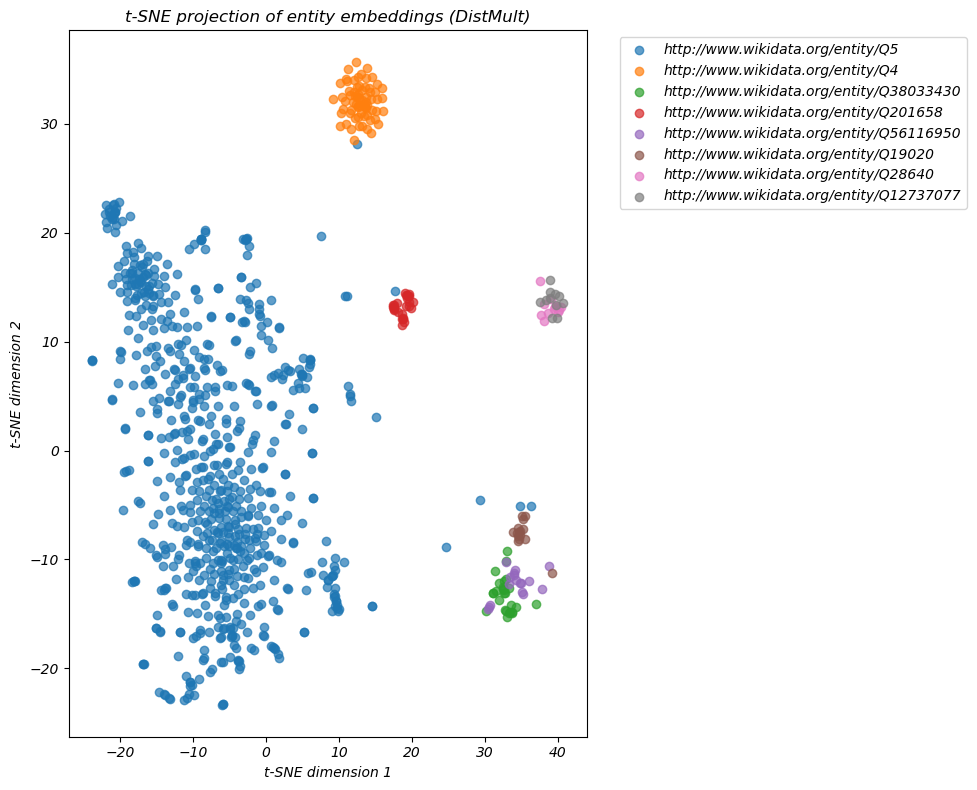

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for cls in top_classes:
    xs = [x for x, lab in zip(plot_x, plot_labels) if lab == cls]
    ys = [yy for yy, lab in zip(plot_y, plot_labels) if lab == cls]
    plt.scatter(xs, ys, label=cls, alpha=0.7)

plt.title("t-SNE projection of entity embeddings (DistMult)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

We applied t-SNE to project entity embeddings into a 2D space and colored the points according to their ontology class.

The visualization reveals partial clustering of entities. Some classes form compact and well-separated clusters, indicating that the embedding captures meaningful semantic similarities.

However, a large portion of the entities is grouped into a dense and dispersed cluster, suggesting that some classes are not clearly distinguishable. This may be due to the heterogeneity of the knowledge graph and the presence of broad or overlapping categories.

Additionally, some noise is introduced by external entities and generic RDF nodes, which affects the clarity of the clustering.

Overall, the embedding captures local semantic structure but does not perfectly separate all entity classes.

# 6.3 — Relation Behavior

DistMult performs particularly well on symmetric relations, as its scoring function is inherently symmetric with respect to head and tail entities.
In contrast, TransE models relations as translations, which makes it less suitable for capturing symmetric patterns.

DistMult performs particularly well on symmetric relations, as its scoring function is inherently symmetric with respect to head and tail entities.
In contrast, TransE models relations as translations, which makes it less suitable for capturing symmetric patterns.

TransE is better suited for modeling inverse relations, since it represents relations as translations in vector space.
This allows inverse relations to be naturally captured through opposite translation vectors.

DistMult, however, is limited in this regard because its symmetric scoring function cannot distinguish directional asymmetry.

For compositional relations, TransE can capture simple patterns through vector addition, where multiple relations combine into a single translation.
However, both TransE and DistMult remain limited when modeling complex multi-hop dependencies.
More advanced models such as ComplEx or RotatE are generally better suited for capturing such patterns.

The experimental results show that DistMult outperforms TransE on this dataset.
This suggests that the knowledge graph contains a significant proportion of symmetric or many-to-many relations, which are better captured by DistMult.

While TransE is theoretically better suited for inverse and compositional relations, these patterns appear to be less dominant in the dataset.

Overall, the performance of embedding models strongly depends on the type of relations present in the knowledge graph.

# 7 — Critical Reflection

The quality of predicate alignment has a direct impact on embedding performance.
If relations are incorrectly aligned or merged despite having slightly different semantics, the model learns inconsistent patterns.

In our case, the integration of multiple sources (custom ontology and Wikidata) likely introduced some misalignment, which contributes to noise in the embedding space and reduces semantic clarity.

The quality of predicate alignment has a direct impact on embedding performance.
If relations are incorrectly aligned or merged despite having slightly different semantics, the model learns inconsistent patterns.

In our case, the integration of multiple sources (custom ontology and Wikidata) likely introduced some misalignment, which contributes to noise in the embedding space and reduces semantic clarity.

Ontology modeling choices strongly influence embedding quality.
In our graph, the coexistence of different types of entities (persons, films, genres) and the use of broad or heterogeneous relations limit the model’s ability to clearly separate semantic categories.

This is reflected in the t-SNE visualization, where clusters are only partially separated.

Knowledge graphs typically follow the open-world assumption, meaning that missing facts are not necessarily false.
However, embedding models rely on negative sampling, where unobserved triples are treated as negative examples.

This creates a fundamental mismatch: some “negative” samples may actually correspond to true but missing facts.

This discrepancy can negatively impact embedding quality and evaluation.

Knowledge graphs typically follow the open-world assumption, meaning that missing facts are not necessarily false.
However, embedding models rely on negative sampling, where unobserved triples are treated as negative examples.

This creates a fundamental mismatch: some “negative” samples may actually correspond to true but missing facts.

This discrepancy can negatively impact embedding quality and evaluation.

# 8 - Comparison between rule-based and embedding


Person(?p) ∧ actedIn(?p, ?m) → relatedToMovie(?p, ?m)

We defined a simple SWRL rule based on our domain:

Person(?p) ∧ actedIn(?p, ?m) → relatedToMovie(?p, ?m)

This rule explicitly captures a semantic relationship between actors and movies.

We then analyzed whether a similar pattern could be observed in the embedding space.
While embedding models such as DistMult do not represent relations as explicit logical rules, we observed that actors are often located close to movies they are associated with in the embedding space.

For example, entities such as "LeonardoDiCaprio" are close to movie entities like "Inception" or "Titanic", suggesting that the model implicitly captures this relationship.

However, unlike rule-based reasoning, this relationship is not exact or guaranteed.
Embedding-based reasoning is approximate and depends on statistical patterns in the data.